In [1]:
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2018.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2019.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2020.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2021.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2022.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2023.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2024.json
!wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/2025.json

print("Semua file JSON berhasil diunduh")

Semua file JSON berhasil diunduh


In [2]:
import json
import os
import pandas as pd

tahun_mapping = {
    118: {"tahun_asli": 2018, "file_name": "2018.json"},
    119: {"tahun_asli": 2019, "file_name": "2019.json"},
    120: {"tahun_asli": 2020, "file_name": "2020.json"},
    121: {"tahun_asli": 2021, "file_name": "2021.json"},
    122: {"tahun_asli": 2022, "file_name": "2022.json"},
    123: {"tahun_asli": 2023, "file_name": "2023.json"},
    124: {"tahun_asli": 2024, "file_name": "2024.json"},
    125: {"tahun_asli": 2025, "file_name": "2025.json"},
}

all_records = []

for kode_th, info in tahun_mapping.items():

    file_path = info["file_name"]
    tahun_asli = info["tahun_asli"]

    with open(file_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)

    list_wilayah = json_data["vervar"]
    list_bulan = json_data["turtahun"]
    data_content = json_data["datacontent"]

    for wil in list_wilayah:

        id_wil = str(wil["val"])
        nama_wil = wil["label"]

        for bln in list_bulan:

            id_bln = str(bln["val"])
            nama_bln = bln["label"]

            if id_bln == "13":
                continue

            key_content = f"{id_wil}5800{kode_th}{id_bln}"

            nilai = data_content.get(key_content, None)

            if nilai is not None:

                all_records.append({
                    "Tahun": tahun_asli,
                    "Bulan_Num": int(id_bln),
                    "Bulan": nama_bln,
                    "Kode_Wilayah": id_wil,
                    "Nama_Wilayah": nama_wil,
                    "Produksi_Beras_Ton": nilai
                })

df = pd.DataFrame(all_records)

df["Tanggal"] = pd.to_datetime(
    df["Tahun"].astype(str)
    + "-"
    + df["Bulan_Num"].astype(str)
    + "-01"
)

print(df.shape)

df.head()

(3704, 7)


,Tahun,Bulan_Num,Bulan,Kode_Wilayah,Nama_Wilayah,Produksi_Beras_Ton,Tanggal
0,2018,1,Januari,3501,Kabupaten Pacitan,1788.78,2018-01-01
1,2018,2,Februari,3501,Kabupaten Pacitan,5341.77,2018-02-01
2,2018,3,Maret,3501,Kabupaten Pacitan,13171.23,2018-03-01
3,2018,4,April,3501,Kabupaten Pacitan,7162.66,2018-04-01
4,2018,5,Mei,3501,Kabupaten Pacitan,4080.21,2018-05-01


In [3]:
df["Tahun"] = df["Tahun"].astype(int)

df_kab_kota = df[
    ~df["Nama_Wilayah"].str.contains(
        "Jawa Timur",
        case=False,
        na=False
    )
]

df_tahunan = (
    df_kab_kota
    .groupby(
        ["Tahun","Kode_Wilayah","Nama_Wilayah"]
    )["Produksi_Beras_Ton"]
    .sum()
    .reset_index()
)

df_tahunan.head()

,Tahun,Kode_Wilayah,Nama_Wilayah,Produksi_Beras_Ton
0,2018,3501,Kabupaten Pacitan,51518.85
1,2018,3502,Kabupaten Ponorogo,216717.19
2,2018,3503,Kabupaten Trenggalek,69263.56
3,2018,3504,Kabupaten Tulungagung,124588.43
4,2018,3505,Kabupaten Blitar,128778.44


In [4]:
print(df.shape)
print(df_tahunan.shape)

display(df.head())
display(df_tahunan.head())

(3704, 7)
(304, 4)


,Tahun,Bulan_Num,Bulan,Kode_Wilayah,Nama_Wilayah,Produksi_Beras_Ton,Tanggal
0,2018,1,Januari,3501,Kabupaten Pacitan,1788.78,2018-01-01
1,2018,2,Februari,3501,Kabupaten Pacitan,5341.77,2018-02-01
2,2018,3,Maret,3501,Kabupaten Pacitan,13171.23,2018-03-01
3,2018,4,April,3501,Kabupaten Pacitan,7162.66,2018-04-01
4,2018,5,Mei,3501,Kabupaten Pacitan,4080.21,2018-05-01


,Tahun,Kode_Wilayah,Nama_Wilayah,Produksi_Beras_Ton
0,2018,3501,Kabupaten Pacitan,51518.85
1,2018,3502,Kabupaten Ponorogo,216717.19
2,2018,3503,Kabupaten Trenggalek,69263.56
3,2018,3504,Kabupaten Tulungagung,124588.43
4,2018,3505,Kabupaten Blitar,128778.44


In [5]:
!pip -q install prophet folium branca

import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import folium
from folium.plugins import MarkerCluster, Fullscreen, MiniMap
from branca.colormap import linear
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

for y in range(2018, 2026):
    if not os.path.exists(f"{y}.json"):
        !wget -q https://github.com/ahocool-aisi555/GIS/raw/refs/heads/main/{y}.json

mapping = {
    118: {"tahun": 2018, "file": "2018.json"},
    119: {"tahun": 2019, "file": "2019.json"},
    120: {"tahun": 2020, "file": "2020.json"},
    121: {"tahun": 2021, "file": "2021.json"},
    122: {"tahun": 2022, "file": "2022.json"},
    123: {"tahun": 2023, "file": "2023.json"},
    124: {"tahun": 2024, "file": "2024.json"},
    125: {"tahun": 2025, "file": "2025.json"},
}
records=[]
for kode, info in mapping.items():
    with open(info["file"], "r", encoding="utf-8") as f:
        data=json.load(f)
    for wil in data["vervar"]:
        id_wil=str(wil["val"])
        nama_wil=wil["label"]
        for bln in data["turtahun"]:
            id_bln=str(bln["val"])
            if id_bln == "13":
                continue
            key=f"{id_wil}5800{kode}{id_bln}"
            nilai=data["datacontent"].get(key)
            if nilai is not None:
                records.append({
                    "Tanggal": pd.to_datetime(f"{info['tahun']}-{int(id_bln)}-01"),
                    "Tahun": info["tahun"],
                    "Bulan_Num": int(id_bln),
                    "Bulan": bln["label"],
                    "Kode_Wilayah": id_wil,
                    "Nama_Wilayah": nama_wil,
                    "Produksi_Beras_Ton": float(nilai)
                })

df=pd.DataFrame(records).sort_values(["Kode_Wilayah","Tanggal"]).reset_index(drop=True)
df_kab=df[~df["Nama_Wilayah"].str.contains("Jawa Timur", case=False, na=False)].copy()
df_tahunan=df_kab.groupby(["Tahun","Kode_Wilayah","Nama_Wilayah"], as_index=False)["Produksi_Beras_Ton"].sum()
print("Jumlah data:", df.shape)
display(df.head())

# STATISTIK DESKRIPTIF
stat_tahunan = df_tahunan.groupby("Tahun")["Produksi_Beras_Ton"].agg(
    Total="sum", Mean="mean", Median="median", Std="std", Min="min", Max="max"
).reset_index()
display(stat_tahunan)

top10_per_tahun = df_tahunan.sort_values(["Tahun","Produksi_Beras_Ton"], ascending=[True, False]) \
    .groupby("Tahun").head(10).reset_index(drop=True)
top10_per_tahun["Peringkat"] = top10_per_tahun.groupby("Tahun").cumcount()+1
display(top10_per_tahun[["Tahun","Peringkat","Nama_Wilayah","Produksi_Beras_Ton"]])

Jumlah data: (3704, 7)


,Tanggal,Tahun,Bulan_Num,Bulan,Kode_Wilayah,Nama_Wilayah,Produksi_Beras_Ton
0,2018-01-01,2018,1,Januari,35000,Jawa Timur,121401.55
1,2018-02-01,2018,2,Februari,35000,Jawa Timur,551786.90
2,2018-03-01,2018,3,Maret,35000,Jawa Timur,1317374.16
3,2018-04-01,2018,4,April,35000,Jawa Timur,772895.13
4,2018-05-01,2018,5,Mei,35000,Jawa Timur,364943.65


,Tahun,Total,Mean,Median,Std,Min,Max
0,2018,5861191.59,154241.883947,141288.530,132717.931132,2402.42,515078.37
1,2019,5503725.94,144834.893158,128349.815,126085.140349,2048.41,482376.06
2,2020,5742176.67,151109.912368,124235.275,132722.547922,2576.31,511629.45
3,2021,5652705.10,148755.397368,132776.720,126278.905652,2549.27,457699.04
4,2022,5500801.88,144757.944211,122037.755,128825.593189,2906.13,521919.84
5,2023,5607131.53,147556.092895,130875.930,126339.111436,1901.31,461188.28
6,2024,5352936.04,140866.737895,115047.025,124978.976007,1991.89,448245.88
7,2025,6148189.18,161794.452105,139172.060,138648.621939,1746.67,508126.15


,Tahun,Peringkat,Nama_Wilayah,Produksi_Beras_Ton
0,2018,1,Kabupaten Lamongan,515078.37
1,2018,2,Kabupaten Bojonegoro,432278.06
2,2018,3,Kabupaten Ngawi,428974.56
3,2018,4,Kabupaten Jember,395683.55
4,2018,5,Kabupaten Tuban,324125.86
...,...,...,...,...
75,2025,6,Kabupaten Madiun,277313.90
76,2025,7,Kabupaten Banyuwangi,261938.65
77,2025,8,Kabupaten Jombang,255012.37
78,2025,9,Kabupaten Ponorogo,251928.35


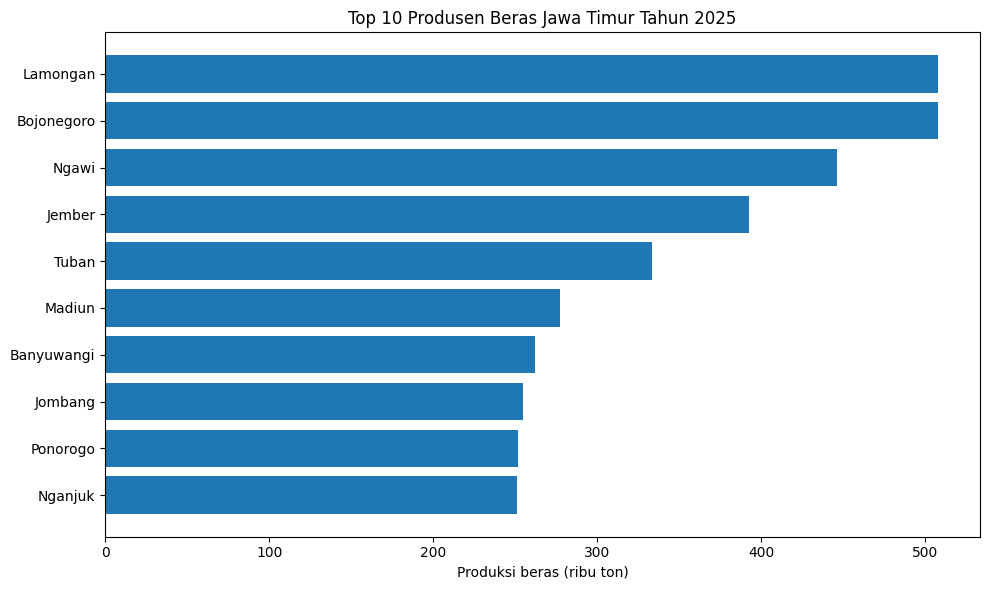

In [6]:
# GRAFIK TOP 10 TAHUN 2025
plt.figure(figsize=(10,6))
top2025 = top10_per_tahun[top10_per_tahun["Tahun"]==2025].sort_values("Produksi_Beras_Ton")
plt.barh(top2025["Nama_Wilayah"].str.replace("Kabupaten ", ""), top2025["Produksi_Beras_Ton"]/1000)
plt.title("Top 10 Produsen Beras Jawa Timur Tahun 2025")
plt.xlabel("Produksi beras (ribu ton)")
plt.tight_layout()
plt.savefig("grafik_top10_2025.png", dpi=200)
plt.show()

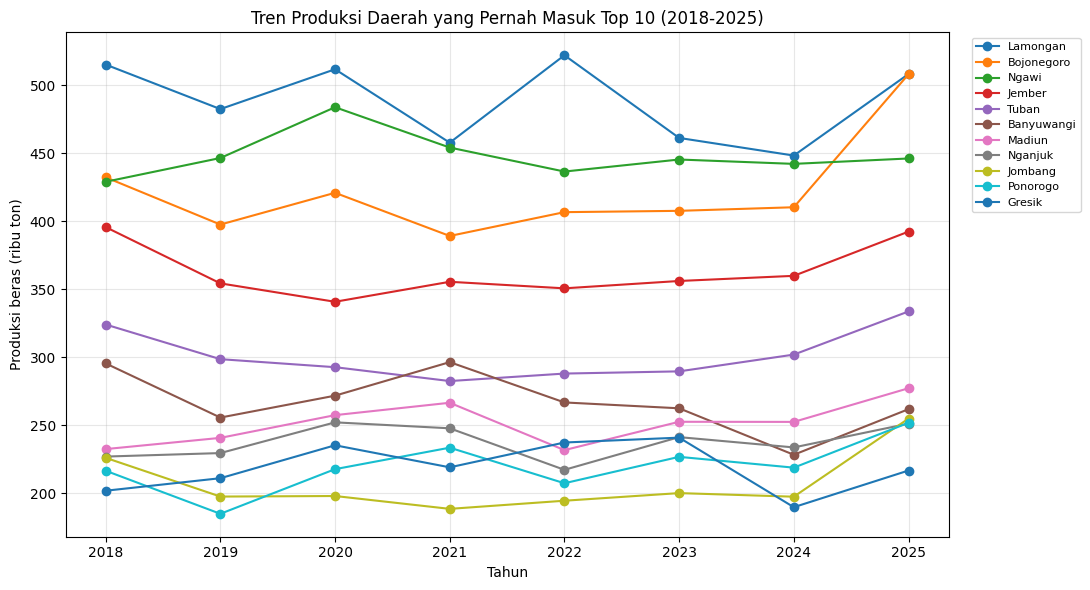

In [7]:
# GRAFIK TREN TOP 10
plt.figure(figsize=(11,6))
wilayah_top = top10_per_tahun["Nama_Wilayah"].unique()
for wilayah in wilayah_top:
    data_plot = df_tahunan[df_tahunan["Nama_Wilayah"]==wilayah]
    plt.plot(data_plot["Tahun"], data_plot["Produksi_Beras_Ton"]/1000, marker="o", label=wilayah.replace("Kabupaten ",""))
plt.title("Tren Produksi Daerah yang Pernah Masuk Top 10 (2018-2025)")
plt.xlabel("Tahun")
plt.ylabel("Produksi beras (ribu ton)")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("grafik_tren_top10.png", dpi=200)
plt.show()

In [8]:
# PETA INTERAKTIF FOLIUM
# Koordinat pusat wilayah top 10, cukup untuk visualisasi bubble map praktikum.
coords = {
    "Kabupaten Lamongan": [-7.1195,112.4140],
    "Kabupaten Bojonegoro": [-7.1502,111.8817],
    "Kabupaten Ngawi": [-7.4033,111.4461],
    "Kabupaten Jember": [-8.1737,113.7005],
    "Kabupaten Tuban": [-6.8946,112.0649],
    "Kabupaten Madiun": [-7.6298,111.5239],
    "Kabupaten Banyuwangi": [-8.2192,114.3691],
    "Kabupaten Jombang": [-7.5468,112.2331],
    "Kabupaten Ponorogo": [-7.8651,111.4690],
    "Kabupaten Nganjuk": [-7.6029,111.9018],
    "Kabupaten Gresik": [-7.1567,112.6555]
}
map_data = top10_per_tahun[top10_per_tahun["Tahun"]==2025].copy()
map_data["lat"] = map_data["Nama_Wilayah"].map(lambda x: coords.get(x, [np.nan,np.nan])[0])
map_data["lon"] = map_data["Nama_Wilayah"].map(lambda x: coords.get(x, [np.nan,np.nan])[1])
map_data = map_data.dropna(subset=["lat","lon"])

m = folium.Map(location=[-7.55, 112.4], zoom_start=8, tiles="CartoDB positron")
Fullscreen().add_to(m)
MiniMap(toggle_display=True).add_to(m)
cluster = MarkerCluster().add_to(m)
max_prod = map_data["Produksi_Beras_Ton"].max()
colormap = linear.YlOrRd_09.scale(map_data["Produksi_Beras_Ton"].min(), max_prod)
colormap.caption = "Produksi Beras 2025 (Ton)"
colormap.add_to(m)

for _, row in map_data.iterrows():
    radius = 8 + (row["Produksi_Beras_Ton"] / max_prod) * 24
    popup = f"""
    <b>{row['Nama_Wilayah']}</b><br>
    Peringkat: {int(row['Peringkat'])}<br>
    Produksi: {row['Produksi_Beras_Ton']:,.2f} ton
    """
    folium.CircleMarker(
        location=[row["lat"], row["lon"]], radius=radius,
        color=colormap(row["Produksi_Beras_Ton"]), fill=True,
        fill_opacity=0.65, popup=folium.Popup(popup, max_width=300),
        tooltip=row["Nama_Wilayah"]
    ).add_to(cluster)

m.save("peta_interaktif_top10_beras_jatim_2025.html")
m

In [9]:
# FUNGSI EVALUASI MODEL BERDASARKAN TRAIN-TEST
TARGET = "Kabupaten Lamongan"
series = df_kab[df_kab["Nama_Wilayah"]==TARGET].set_index("Tanggal")["Produksi_Beras_Ton"].asfreq("MS")
train = series.iloc[:-12]
test = series.iloc[-12:]

def eval_model(y_true, y_pred, nama):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"Model": nama, "MAE": mae, "RMSE": rmse}

hasil_eval=[]

# ARIMA
fit_arima = ARIMA(train, order=(1,1,1)).fit()
pred_arima_test = fit_arima.forecast(steps=12)
hasil_eval.append(eval_model(test, pred_arima_test, "ARIMA"))

# ARIMA + Dekomposisi
res = seasonal_decompose(train, model="additive", period=12)
seasonal_pattern = res.seasonal.groupby(res.seasonal.index.month).mean()
deseasonal = train - train.index.month.map(seasonal_pattern)
fit_dec = ARIMA(deseasonal.dropna(), order=(1,1,1)).fit()
pred_dec_base = fit_dec.forecast(steps=12)
pred_dec_test = pred_dec_base + [seasonal_pattern[m] for m in test.index.month]
hasil_eval.append(eval_model(test, pred_dec_test, "ARIMA + Dekomposisi"))

# SARIMAX
fit_sarimax = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
pred_sarimax_test = fit_sarimax.forecast(steps=12)
hasil_eval.append(eval_model(test, pred_sarimax_test, "SARIMAX"))

# Prophet
prophet_train = train.reset_index().rename(columns={"Tanggal":"ds", "Produksi_Beras_Ton":"y"})
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive")
model_prophet.fit(prophet_train)
future_test = model_prophet.make_future_dataframe(periods=12, freq="MS")
forecast_test = model_prophet.predict(future_test).tail(12)
pred_prophet_test = forecast_test["yhat"].clip(lower=0).values
hasil_eval.append(eval_model(test, pred_prophet_test, "Prophet"))

df_eval = pd.DataFrame(hasil_eval).sort_values("RMSE")
display(df_eval)


,Model,MAE,RMSE
1,ARIMA + Dekomposisi,11764.579963,15233.804997
3,Prophet,14040.461356,17477.137465
2,SARIMAX,14739.287028,18577.723151
0,ARIMA,21445.734242,34970.680477


In [10]:
# FORECAST 10 TAHUN / 120 BULAN
JUMLAH_BULAN_PREDIKSI = 120
future_dates = pd.date_range(series.index.max()+pd.DateOffset(months=1), periods=JUMLAH_BULAN_PREDIKSI, freq="MS")

# Fit ulang dengan seluruh data
fit_arima_full = ARIMA(series, order=(1,1,1)).fit()
forecast_arima = fit_arima_full.forecast(steps=JUMLAH_BULAN_PREDIKSI)

res_full = seasonal_decompose(series, model="additive", period=12)
seasonal_full = res_full.seasonal.groupby(res_full.seasonal.index.month).mean()
deseasonal_full = series - series.index.month.map(seasonal_full)
fit_dec_full = ARIMA(deseasonal_full.dropna(), order=(1,1,1)).fit()
base_dec = fit_dec_full.forecast(steps=JUMLAH_BULAN_PREDIKSI)
forecast_dec = base_dec + [seasonal_full[m] for m in future_dates.month]
forecast_dec.index = future_dates

fit_sarimax_full = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12),
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
forecast_sarimax = fit_sarimax_full.forecast(steps=JUMLAH_BULAN_PREDIKSI)
forecast_sarimax.index = future_dates

prophet_full = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode="additive")
prophet_full.fit(series.reset_index().rename(columns={"Tanggal":"ds", "Produksi_Beras_Ton":"y"}))
future_prophet = prophet_full.make_future_dataframe(periods=JUMLAH_BULAN_PREDIKSI, freq="MS")
forecast_prophet = prophet_full.predict(future_prophet).tail(JUMLAH_BULAN_PREDIKSI)

# Tabel forecast bulanan
df_forecast = pd.DataFrame({
    "Tanggal": future_dates,
    "ARIMA": forecast_arima.values,
    "ARIMA_Dekomposisi": forecast_dec.values,
    "SARIMAX": forecast_sarimax.values,
    "Prophet": forecast_prophet["yhat"].clip(lower=0).values,
    "Prophet_Bawah": forecast_prophet["yhat_lower"].clip(lower=0).values,
    "Prophet_Atas": forecast_prophet["yhat_upper"].clip(lower=0).values,
})
display(df_forecast.head(15))
df_forecast.to_csv("forecast_10_tahun_lamongan.csv", index=False)


,Tanggal,ARIMA,ARIMA_Dekomposisi,SARIMAX,Prophet,Prophet_Bawah,Prophet_Atas
0,2026-01-01,30107.873696,4391.952094,7435.199596,742.636891,0.000000,20323.748819
1,2026-02-01,37269.508771,38943.114930,43658.640295,45158.354645,25970.275880,64577.366330
2,2026-03-01,39121.883338,118401.434567,126263.193238,118092.500371,97508.128761,138784.170541
3,2026-04-01,39601.004586,58236.300608,54023.839871,45276.200109,25621.616270,65055.036977
4,2026-05-01,39724.930478,20693.379013,23592.075858,25171.736701,5355.382968,46481.932616
5,2026-06-01,39756.984215,59574.536347,59796.160442,64727.198427,44127.829773,83887.961735
6,2026-07-01,39765.274993,44264.446905,52011.934153,42620.336713,23333.427970,62022.877207
7,2026-08-01,39767.419423,55232.348213,52280.956359,49572.758985,29785.156462,70007.317269
8,2026-09-01,39767.974086,57219.812856,49138.413451,53249.312034,33893.341120,73398.055523
9,2026-10-01,39768.117550,17538.762559,29787.129122,17214.668843,0.000000,36774.963738


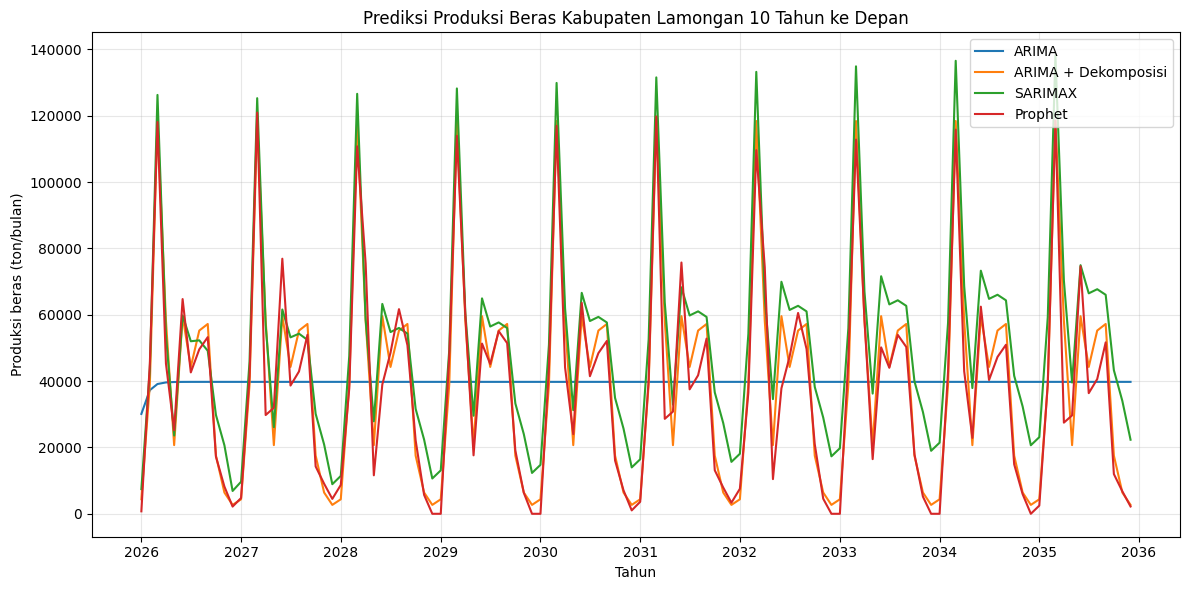

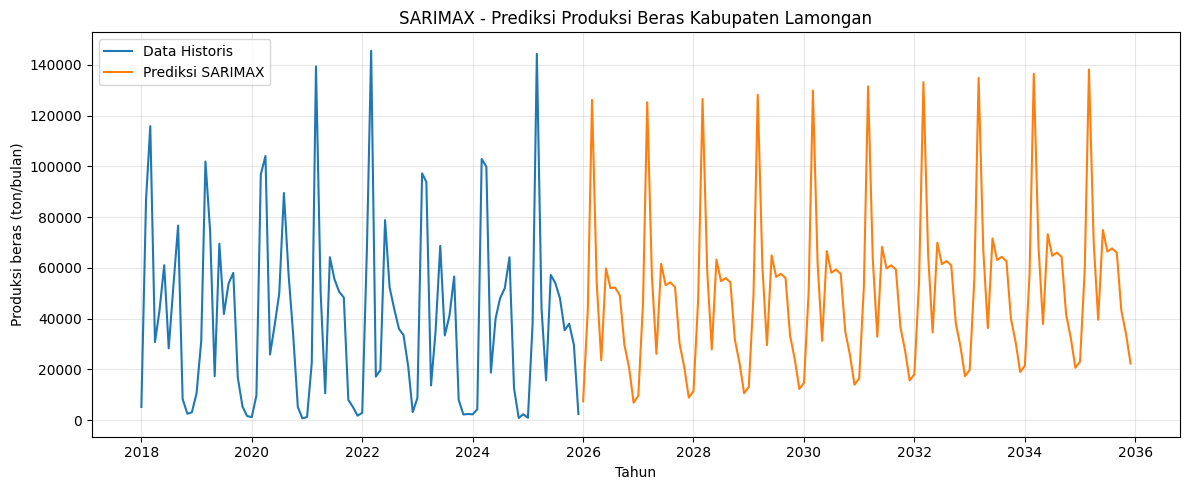

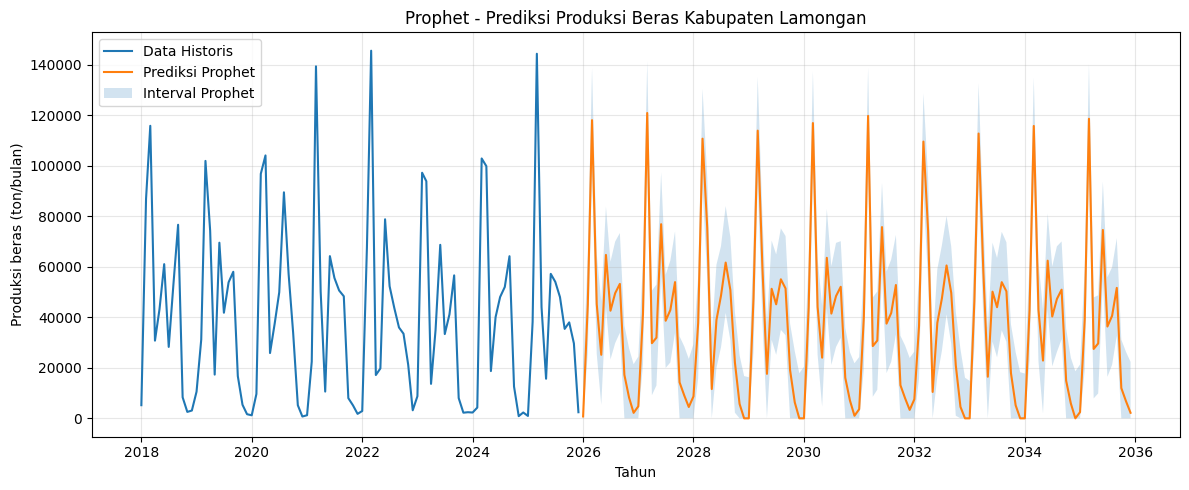

In [11]:
# GRAFIK PERBANDINGAN FORECAST
plt.figure(figsize=(12,6))
plt.plot(df_forecast["Tanggal"], df_forecast["ARIMA"], label="ARIMA")
plt.plot(df_forecast["Tanggal"], df_forecast["ARIMA_Dekomposisi"], label="ARIMA + Dekomposisi")
plt.plot(df_forecast["Tanggal"], df_forecast["SARIMAX"], label="SARIMAX")
plt.plot(df_forecast["Tanggal"], df_forecast["Prophet"], label="Prophet")
plt.title(f"Prediksi Produksi Beras {TARGET} 10 Tahun ke Depan")
plt.xlabel("Tahun")
plt.ylabel("Produksi beras (ton/bulan)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("forecast_perbandingan_model_10_tahun.png", dpi=200)
plt.show()

# GRAFIK KHUSUS SARIMAX DAN PROPHET
plt.figure(figsize=(12,5))
plt.plot(series.index, series.values, label="Data Historis")
plt.plot(df_forecast["Tanggal"], df_forecast["SARIMAX"], label="Prediksi SARIMAX")
plt.title(f"SARIMAX - Prediksi Produksi Beras {TARGET}")
plt.xlabel("Tahun")
plt.ylabel("Produksi beras (ton/bulan)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("forecast_sarimax_10_tahun.png", dpi=200)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(series.index, series.values, label="Data Historis")
plt.plot(df_forecast["Tanggal"], df_forecast["Prophet"], label="Prediksi Prophet")
plt.fill_between(df_forecast["Tanggal"], df_forecast["Prophet_Bawah"], df_forecast["Prophet_Atas"], alpha=0.2, label="Interval Prophet")
plt.title(f"Prophet - Prediksi Produksi Beras {TARGET}")
plt.xlabel("Tahun")
plt.ylabel("Produksi beras (ton/bulan)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("forecast_prophet_10_tahun.png", dpi=200)
plt.show()